In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Diamond dtaset from github
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/diamonds.csv"
df = pd.read_csv(url)
df.shape

(53940, 10)

In [4]:
# Dataset overview
print("Dataset shape: ", df.shape)
print("Dataset columns: ", df.columns.tolist())
print("first 5 rows: \n", df.head())
# Data types and missing values
print("Data types: ", df.dtypes)
print("Missing values: ", df.isnull().sum())
# Summary statistics
print("Summary statistics: \n", df.describe())

Dataset shape:  (53940, 10)
Dataset columns:  ['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'price', 'x', 'y', 'z']
first 5 rows: 
    carat      cut color clarity  depth  table  price     x     y     z
0   0.23    Ideal     E     SI2   61.5   55.0    326  3.95  3.98  2.43
1   0.21  Premium     E     SI1   59.8   61.0    326  3.89  3.84  2.31
2   0.23     Good     E     VS1   56.9   65.0    327  4.05  4.07  2.31
3   0.29  Premium     I     VS2   62.4   58.0    334  4.20  4.23  2.63
4   0.31     Good     J     SI2   63.3   58.0    335  4.34  4.35  2.75
Data types:  carat      float64
cut            str
color          str
clarity        str
depth      float64
table      float64
price        int64
x          float64
y          float64
z          float64
dtype: object
Missing values:  carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64
Summary statistics: 
               carat         depth 

In [5]:
# Data cleaning
duplicates = df.duplicated().sum()
print("Number of duplicate rows: ", duplicates)

Number of duplicate rows:  146


In [6]:
if duplicates > 0:
    df = df.drop_duplicates()
    print("Duplicates removed. New dataset shape: ", df.shape)


Duplicates removed. New dataset shape:  (53794, 10)


In [8]:
# Checking for impossible values.
invalid_dimension_mask = (df['x'] <= 0) | (df['y'] <= 0) | (df['z'] <= 0)
invalid_dimension_count = invalid_dimension_mask.sum()
print("Number of rows with invalid dimensions: ", invalid_dimension_count)

Number of rows with invalid dimensions:  19


In [9]:
# Remove rows with invalid dimensions
if invalid_dimension_count > 0:
    df = df[~invalid_dimension_mask]
    print("Invalid dimension rows removed. New dataset shape: ", df.shape)

Invalid dimension rows removed. New dataset shape:  (53775, 10)


In [10]:
# Percentile based trimming for removing extreme outliers
df_before_trim = df.copy()

depth_low, depth_high = np.percentile(df['depth'], [5, 95])
table_low, table_high = np.percentile(df['table'], [5, 95])

trim_mask = (
    (df['depth'] >= depth_low) & (df['depth'] <= depth_high) &
    (df['table'] >= table_low) & (df['table'] <= table_high)
)

df = df[trim_mask].copy()
print("Dataset shape after trimming: ", df.shape)


Dataset shape after trimming:  (46548, 10)


In [11]:
# Analysis of the filtered data
correlation_matrix = df.corr(numeric_only=True)
print("Correlation matrix: \n", correlation_matrix)

Correlation matrix: 
           carat     depth     table     price         x         y         z
carat  1.000000  0.019913  0.189833  0.927937  0.980042  0.973197  0.960989
depth  0.019913  1.000000 -0.198304 -0.005734 -0.014947 -0.016205  0.065789
table  0.189833 -0.198304  1.000000  0.148646  0.189758  0.183577  0.167211
price  0.927937 -0.005734  0.148646  1.000000  0.892727  0.887990  0.873921
x      0.980042 -0.014947  0.189758  0.892727  1.000000  0.992730  0.977357
y      0.973197 -0.016205  0.183577  0.887990  0.992730  1.000000  0.972666
z      0.960989  0.065789  0.167211  0.873921  0.977357  0.972666  1.000000


In [13]:
print("Average price by cut: \n", df.groupby('cut')['price'].mean())

Average price by cut: 
 cut
Fair         4020.050847
Good         3731.684688
Ideal        3467.629083
Premium      4543.544598
Very Good    3947.261279
Name: price, dtype: float64


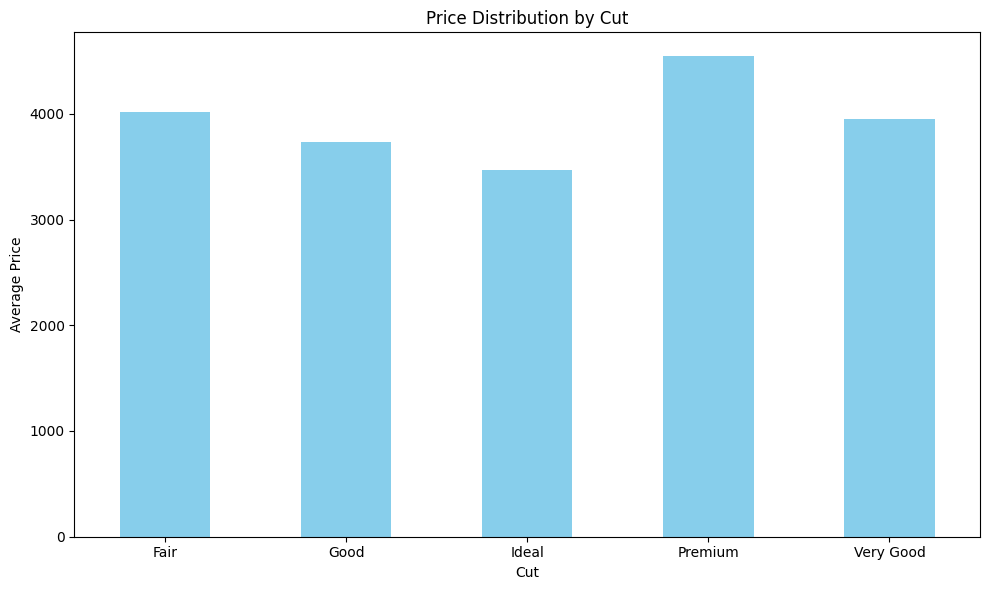

In [14]:
# Plot price distribution based on cut
plt.figure(figsize=(10, 6))
plt.title("Price Distribution by Cut")
mean_prices = df.groupby('cut')['price'].mean()
mean_prices.plot(kind='bar', color='skyblue')
plt.xlabel('Cut')
plt.ylabel('Average Price')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

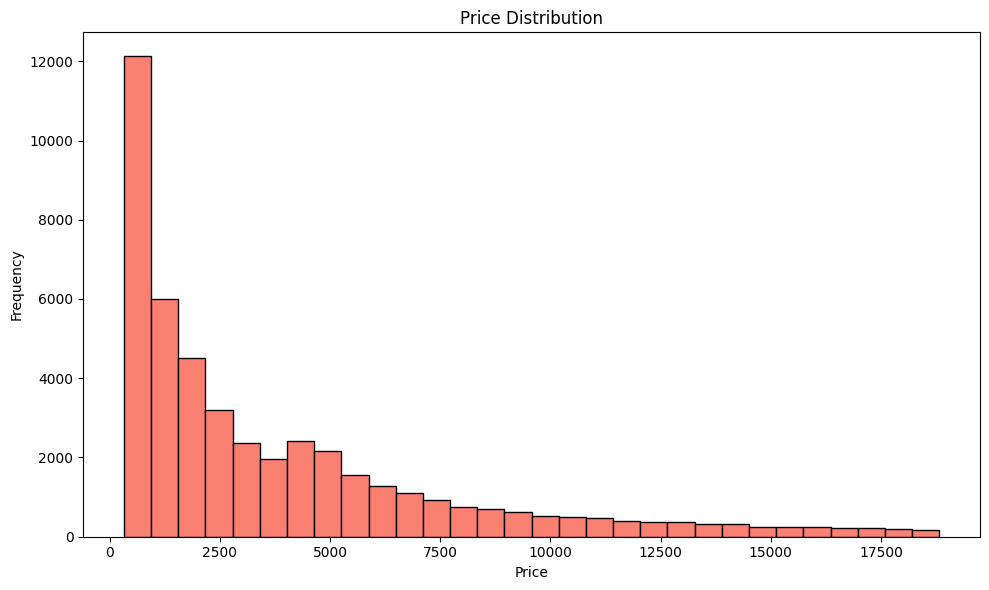

In [15]:
# Histogram of price distribution
plt.figure(figsize=(10, 6))
plt.title("Price Distribution")
plt.hist(df['price'], bins=30, color='salmon', edgecolor='black')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

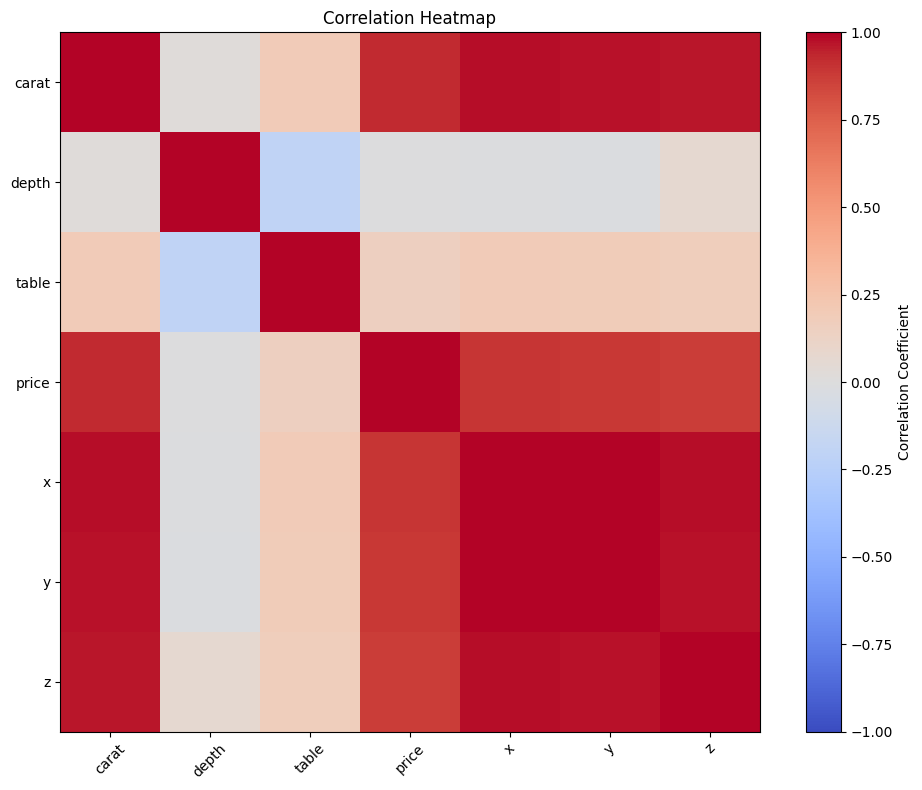

In [16]:
# Correlation heatmap
plt.figure(figsize=(10, 8))
plt.title("Correlation Heatmap")
plt.imshow(correlation_matrix, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(label='Correlation Coefficient')
plt.xticks(range(len(correlation_matrix.columns)), correlation_matrix.columns, rotation=45)
plt.yticks(range(len(correlation_matrix.columns)), correlation_matrix.columns)
plt.tight_layout()
plt.show()